<a href="https://colab.research.google.com/github/tb12tilly-eng/PHSX_221-Lab/blob/main/PHSX221_Lab_1_Brady_Johnson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

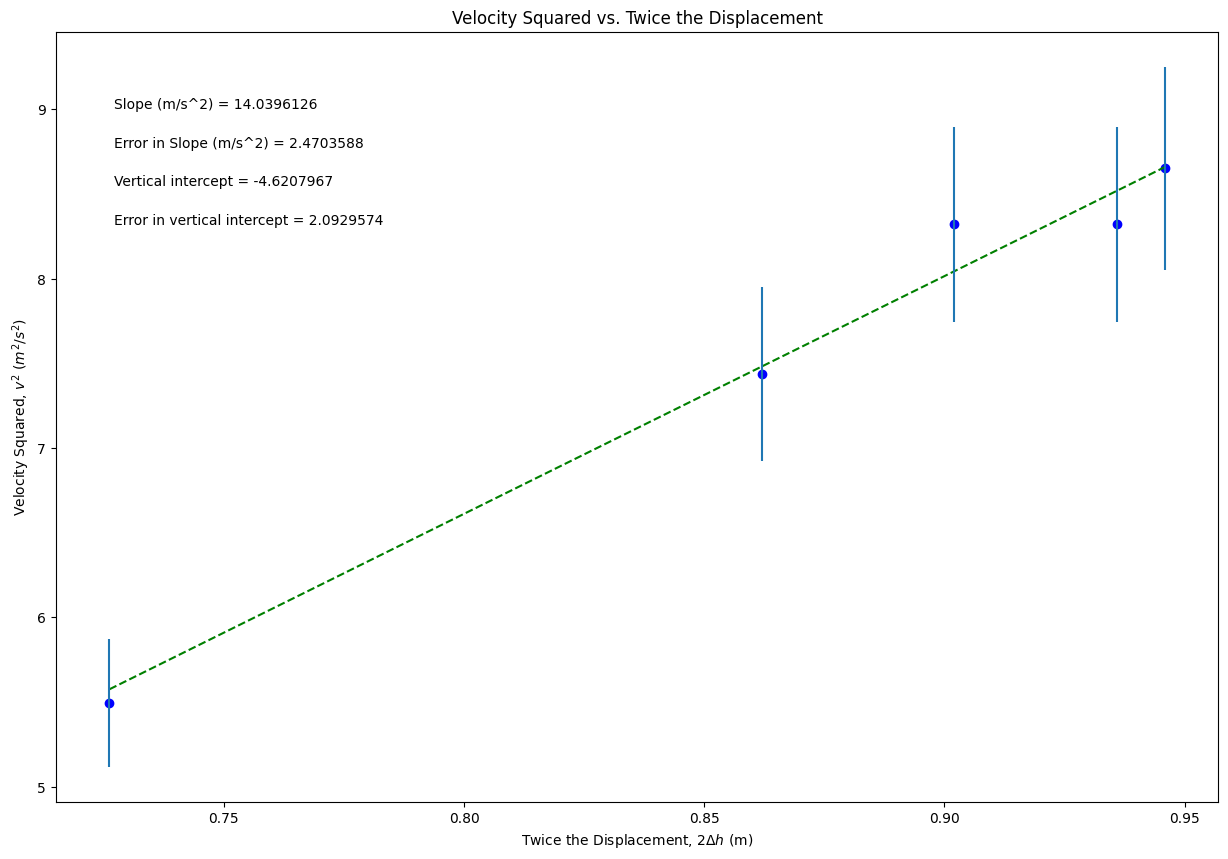

In [ ]:
#PHSX 221 & 223 plotting code
#Brady Johnson
#Updated September 2026

%matplotlib inline
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt

#-----------------------------------------------------------------------#
#----------DATA INPUT SECTION----------

# x-axis data: "Twice the displacement" from your image
twice_displacement = np.array([0.946, 0.936, 0.902, 0.862, 0.726])

# y-axis data: "final v^2" and its uncertainty "dx" directly from your image
v_squared_data = np.array([8.650519, 8.321006, 8.321006, 7.438017, 5.493164])
v_squared_err  = np.array([0.601128, 0.577352, 0.577352, 0.513978, 0.376135])

x = twice_displacement
y = v_squared_data
dy = v_squared_err

plot_title = 'Velocity Squared vs. Twice the Displacement'
x_label = 'Twice the Displacement, $2\\Delta h$ (m)'
y_label = 'Velocity Squared, $v^2$ ($m^2/s^2$)'
slope_units = 'm/s^2'

annotation_placement = 2

#-----------------------------------------------------------------------#
#-----TEMPLATE ALGEBRA MATRICES-----

b, m = np.polynomial.polynomial.polyfit(x, y, 1, w=dy)
fit = b + m * x

def Delta(x, dy):
    D = (sum(1 / dy**2)) * (sum(x**2 / dy**2)) - (sum(x / dy**2))**2
    return D

D = Delta(x, dy)
dm = np.sqrt(1 / D * sum(1 / dy**2))
db = np.sqrt(1 / D * sum(x**2 / dy**2))

#-----------------------------------------------------------------------#
# Drawing the Plot

plt.figure(figsize=(15, 10))
plt.plot(x, fit, color='green', linestyle='--')
plt.scatter(x, y, color='blue', marker='o')

plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(plot_title)
plt.errorbar(x, y, yerr=dy, xerr=None, fmt="none")

xpos, ypos = (0.05, [.9, .85, .8, .75]) if annotation_placement == 2 else (0.75, [.9, .85, .8, .75])

plt.annotate('Slope ({}) = {value:.7f}'.format(slope_units, value=m), (xpos, ypos[0]), xycoords='axes fraction')
plt.annotate('Error in Slope ({}) = {value:.7f}'.format(slope_units, value=dm), (xpos, ypos[1]), xycoords='axes fraction')
plt.annotate('Vertical intercept = {value:.7f}'.format(value=b), (xpos, ypos[2]), xycoords='axes fraction')
plt.annotate('Error in vertical intercept = {value:.7f}'.format(value=db), (xpos, ypos[3]), xycoords='axes fraction')

plt.show()